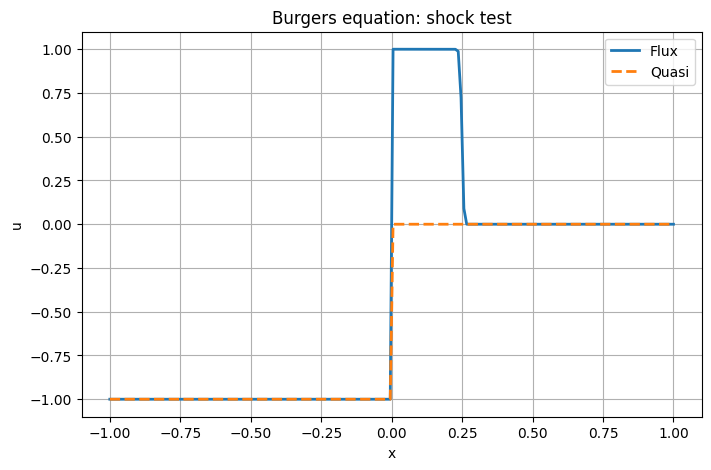

In [11]:
import numpy as np
import matplotlib.pyplot as plt

Nx = 200
x = np.linspace(-1, 1, Nx)
dx = x[1] - x[0]

T = 0.5
CFL = 0.8
dt = CFL * dx
Nt = int(T / dt)

gamma = dt / dx

def u0(x):
    return np.where(x <= 0, -1.0, 0.0)

def flux(u):
    u_new = u.copy()
    for i in range(1, len(u)):
        u_new[i] = u[i] - gamma * 0.5 * (u[i]**2 - u[i-1]**2)
    u_new[0] = u_new[1] 
    return u_new

def quasi(u):
    u_new = u.copy()
    for i in range(1, len(u)):
        u_new[i] = u[i] - gamma * u[i] * (u[i] - u[i-1])
    u_new[0] = u_new[1]
    return u_new

u_f = u0(x)
u_q = u0(x)

for n in range(Nt):
    u_f = flux(u_f)
    u_q = quasi(u_q)


plt.figure(figsize=(8,5))
plt.plot(x, u_f, label="Flux", linewidth=2)
plt.plot(x, u_q, '--', label="Quasi", linewidth=2)
plt.xlabel("x")
plt.ylabel("u")
plt.title("Burgers equation: shock test")
plt.legend()
plt.grid()
plt.show()